In [18]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report, precision_score
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_encoded = pd.read_csv('clean_df_3_single_weapon.csv')

# Categorical columns
categorical_columns = [
    'Agency Type', 'Victim Sex', 'Victim Age', 'Victim Ethnicity',
    'Perpetrator Sex', 'Perpetrator Ethnicity',
    'Relationship Category', 'Region', 'Season'
]

# Encode target variable
# Encode target variable with explicit mapping
target_encoder = LabelEncoder()

# Manually fit the target encoder with desired order
target_encoder.classes_ = np.array(['Non-Firearm', 'Firearm'])

# Use the target encoder to transform the 'Weapon Category' column
df_encoded['Weapon Category'] = target_encoder.transform(df_encoded['Weapon Category'])

labels = ['Non-Firearm', 'Firearm']  # Correct label mapping: 0 -> Non-Firearm, 1 -> Firearm


# Prepare data for label encoding
label_encoders = {}
df_label_encoded = df_encoded.copy()
for col in categorical_columns:
    le = LabelEncoder()
    df_label_encoded[col] = le.fit_transform(df_label_encoded[col])
    label_encoders[col] = le

X_label_encoded = df_label_encoded.drop(columns=['Weapon Category'])
y_label_encoded = df_label_encoded['Weapon Category']

# Prepare data for one-hot encoding
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_onehot_encoded = onehot_encoder.fit_transform(df_encoded[categorical_columns])
X_onehot_encoded = np.hstack((
    X_onehot_encoded,
    df_encoded.drop(columns=categorical_columns + ['Weapon Category']).values
))
y_onehot_encoded = df_encoded['Weapon Category']

# Define scaling and train-test splits
def prepare_data(X, y, use_smote=False):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    if use_smote:
        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)
    return X_train, X_test, y_train, y_test

# Helper functions for evaluation and visualization
def evaluate_model(model, X_test, y_test, y_pred_proba=None, labels=None):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    # print(f"Confusion Matrix:\n{cm}\n")
    print(f"Accuracy: {accuracy:.4f}")
    
    # Use zero_division=0 to avoid warning for undefined precision
    report = classification_report(y_test, y_pred, target_names=labels, zero_division=0)
    print("Classification Report:\n", report)
    
    
    # if y_pred_proba is not None:
    #     print(f"Predicted Probabilities:\n{y_pred_proba[:5]}")  # Show first 5 probabilities

# Train XGBoost with different hyperparameters
def train_xgboost(X_train, y_train, learning_rate, max_depth, scale_pos_weight):
    model = XGBClassifier(
        learning_rate=learning_rate,
        max_depth=max_depth,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        random_state=42
    )
    model.fit(X_train, y_train)
    return model

# Experiment settings
learning_rates = [0.3, 0.1, 0.01]
max_depths = [3, 5, 6]
scale_pos_weights = [1, len(y_label_encoded[y_label_encoded == 0]) / len(y_label_encoded[y_label_encoded == 1])]

# Run experiments for label encoding
print("Label Encoding Results:")

for smote in [False, True]:
    print(f"\n{'With SMOTE' if smote else 'Without SMOTE'}:")
    X_train_label, X_test_label, y_train_label, y_test_label = prepare_data(X_label_encoded, y_label_encoded, use_smote=smote)

    for lr in learning_rates:
        for md in max_depths:
            for spw in scale_pos_weights:
                print(f"\nLearning Rate: {lr}, Max Depth: {md}, Scale Pos Weight: {spw}")
                model_label = train_xgboost(X_train_label, y_train_label, lr, md, spw)
                evaluate_model(model_label, X_test_label, y_test_label, model_label.predict_proba(X_test_label), labels)

# Run experiments for one-hot encoding
print("One-Hot Encoding Results:")

for smote in [False, True]:
    print(f"\n{'With SMOTE' if smote else 'Without SMOTE'}:")
    X_train_onehot, X_test_onehot, y_train_onehot, y_test_onehot = prepare_data(X_onehot_encoded, y_onehot_encoded, use_smote=smote)

    for lr in learning_rates:
        for md in max_depths:
            for spw in scale_pos_weights:
                print(f"\nLearning Rate: {lr}, Max Depth: {md}, Scale Pos Weight: {spw}")
                model_onehot = train_xgboost(X_train_onehot, y_train_onehot, lr, md, spw)
                evaluate_model(model_onehot, X_test_onehot, y_test_onehot, model_onehot.predict_proba(X_test_onehot), labels)


Label Encoding Results:

Without SMOTE:

Learning Rate: 0.3, Max Depth: 3, Scale Pos Weight: 1
Accuracy: 0.7060
Classification Report:
               precision    recall  f1-score   support

 Non-Firearm       0.66      0.22      0.33     10105
     Firearm       0.71      0.94      0.81     20598

    accuracy                           0.71     30703
   macro avg       0.68      0.58      0.57     30703
weighted avg       0.69      0.71      0.65     30703


Learning Rate: 0.3, Max Depth: 3, Scale Pos Weight: 0.4905717170932536
Accuracy: 0.6450
Classification Report:
               precision    recall  f1-score   support

 Non-Firearm       0.47      0.59      0.52     10105
     Firearm       0.77      0.67      0.72     20598

    accuracy                           0.65     30703
   macro avg       0.62      0.63      0.62     30703
weighted avg       0.67      0.65      0.65     30703


Learning Rate: 0.3, Max Depth: 5, Scale Pos Weight: 1
Accuracy: 0.7068
Classification Report:
  

In [19]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report, precision_score
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_encoded = pd.read_csv('clean_df_3_single_weapon.csv')

# Categorical columns
categorical_columns = [
    'Agency Type', 'Victim Sex', 'Victim Age', 'Victim Ethnicity',
    'Perpetrator Sex', 'Perpetrator Ethnicity',
    'Relationship Category', 'Region', 'Season'
]

# Encode target variable
target_encoder = LabelEncoder()
target_encoder.classes_ = np.array(['Non-Firearm', 'Firearm'])
df_encoded['Weapon Category'] = target_encoder.transform(df_encoded['Weapon Category'])
labels = ['Non-Firearm', 'Firearm']

# Prepare data for label encoding
label_encoders = {}
df_label_encoded = df_encoded.copy()
for col in categorical_columns:
    le = LabelEncoder()
    df_label_encoded[col] = le.fit_transform(df_label_encoded[col])
    label_encoders[col] = le

X_label_encoded = df_label_encoded.drop(columns=['Weapon Category'])
y_label_encoded = df_label_encoded['Weapon Category']

# Prepare data for one-hot encoding
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_onehot_encoded = onehot_encoder.fit_transform(df_encoded[categorical_columns])
X_onehot_encoded = np.hstack((
    X_onehot_encoded,
    df_encoded.drop(columns=categorical_columns + ['Weapon Category']).values
))
y_onehot_encoded = df_encoded['Weapon Category']

# Define scaling and train-test splits
def prepare_data(X, y, use_smote=False):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    if use_smote:
        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)
    return X_train, X_test, y_train, y_test

# Train XGBoost with different hyperparameters
def train_xgboost(X_train, y_train, learning_rate, max_depth, scale_pos_weight):
    model = XGBClassifier(
        learning_rate=learning_rate,
        max_depth=max_depth,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        random_state=42
    )
    model.fit(X_train, y_train)
    return model

# Plot labeled confusion matrix
def plot_confusion_matrix(cm, labels, title, filename):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

# Evaluate model and collect results
def evaluate_and_store_results(model, X_test, y_test, labels, params, results_table, experiment_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=labels, output_dict=True, zero_division=0)
    
    # Add results to the table
    results_table.append({
        'Experiment': experiment_name,
        'Learning Rate': params['learning_rate'],
        'Max Depth': params['max_depth'],
        'Scale Pos Weight': params['scale_pos_weight'],
        'Precision Non-Firearm': report['Non-Firearm']['precision'],
        'Recall Non-Firearm': report['Non-Firearm']['recall'],
        'F1 Non-Firearm': report['Non-Firearm']['f1-score'],
        'Precision Firearm': report['Firearm']['precision'],
        'Recall Firearm': report['Firearm']['recall'],
        'F1 Firearm': report['Firearm']['f1-score'],
        'Accuracy': accuracy_score(y_test, y_pred)
    })
    
    # Plot and save confusion matrix
    cm_filename = f"confusion_matrix_{experiment_name}.png"
    plot_confusion_matrix(cm, labels, f"Confusion Matrix: {experiment_name}", cm_filename)

# Main experiment loop
def run_experiments(X, y, encoding_type):
    results_table = []
    learning_rates = [0.3, 0.1, 0.01]
    max_depths = [3, 5, 6]
    scale_pos_weights = [1, len(y[y == 0]) / len(y[y == 1])]
    
    for smote in [False, True]:
        smote_status = 'With SMOTE' if smote else 'Without SMOTE'
        X_train, X_test, y_train, y_test = prepare_data(X, y, use_smote=smote)
        
        for lr in learning_rates:
            for md in max_depths:
                for spw in scale_pos_weights:
                    params = {'learning_rate': lr, 'max_depth': md, 'scale_pos_weight': spw}
                    experiment_name = f"{encoding_type}_{smote_status}_LR{lr}_MD{md}_SPW{spw}"
                    
                    model = train_xgboost(X_train, y_train, **params)
                    evaluate_and_store_results(model, X_test, y_test, labels, params, results_table, experiment_name)
    
    return pd.DataFrame(results_table)

# Run experiments for both encoding strategies
print("Running Label Encoding Experiments...")
label_results = run_experiments(X_label_encoded, y_label_encoded, "Label_Encoding")

print("Running One-Hot Encoding Experiments...")
onehot_results = run_experiments(X_onehot_encoded, y_onehot_encoded, "One-Hot_Encoding")

# Save results to CSV for further analysis
label_results.to_csv("label_encoding_results.csv", index=False)
onehot_results.to_csv("onehot_encoding_results.csv", index=False)


Running Label Encoding Experiments...
Running One-Hot Encoding Experiments...


Preparing data...
Running RandomizedSearchCV...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best Parameters Found: {'colsample_bytree': 0.923330571119153, 'learning_rate': 0.26689728756342773, 'max_depth': 8, 'n_estimators': 169, 'scale_pos_weight': 0.9877700987609598, 'subsample': 0.9254642243837563}

Evaluating Best Model...
Classification Report:
               precision    recall  f1-score   support

 Non-Firearm       0.51      0.40      0.44     15157
     Firearm       0.73      0.81      0.77     30897

    accuracy                           0.67     46054
   macro avg       0.62      0.60      0.61     46054
weighted avg       0.66      0.67      0.66     46054



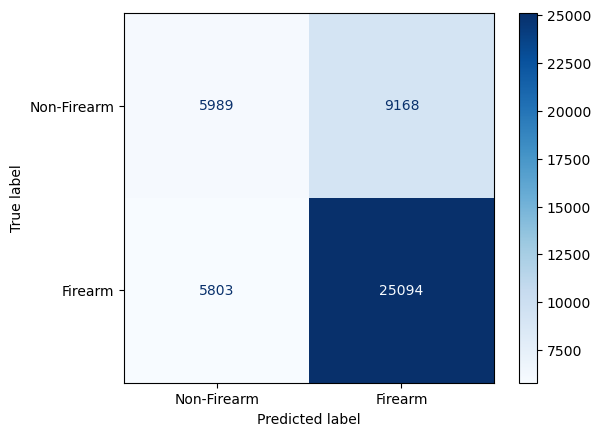

In [21]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
from scipy.stats import uniform, randint

# Load dataset
df_encoded = pd.read_csv('clean_df_3_single_weapon.csv')

# Define categorical columns
categorical_columns = [
    'Agency Type', 'Victim Sex', 'Victim Age', 'Victim Ethnicity',
    'Perpetrator Sex', 'Perpetrator Ethnicity',
    'Relationship Category', 'Region', 'Season'
]

# Encode target variable
df_encoded['Weapon Category'] = df_encoded['Weapon Category'].map({'Non-Firearm': 0, 'Firearm': 1})
labels = ['Non-Firearm', 'Firearm']

# Prepare data for one-hot encoding
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_onehot_encoded = onehot_encoder.fit_transform(df_encoded[categorical_columns])
X_onehot_encoded = np.hstack((
    X_onehot_encoded,
    df_encoded.drop(columns=categorical_columns + ['Weapon Category']).values
))
y = df_encoded['Weapon Category']

# Define scaling and train-test splits with SMOTE
def prepare_data(X, y):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42, stratify=y
    )
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    return X_train, X_test, y_train, y_test

# Define hyperparameter search space
param_distributions = {
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'scale_pos_weight': uniform(0.1, 1.0),
    'n_estimators': randint(50, 200),
    'colsample_bytree': uniform(0.5, 0.5),
    'subsample': uniform(0.5, 0.5)
}

# Train and tune XGBoost using RandomizedSearchCV
def train_xgboost_with_random_search(X_train, y_train):
    model = XGBClassifier(eval_metric='aucpr', random_state=42)
    randomized_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        scoring='f1_weighted',  # Optimize for a balance of precision and recall
        n_iter=50,
        cv=3,
        random_state=42,
        verbose=1,
        n_jobs=-1
    )
    randomized_search.fit(X_train, y_train)
    return randomized_search

# Display and evaluate results
def evaluate_model(model, X_test, y_test, labels):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=labels, zero_division=0))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues')
    return cm

# Main execution flow
print("Preparing data...")
X_train, X_test, y_train, y_test = prepare_data(X_onehot_encoded, y)

print("Running RandomizedSearchCV...")
best_model = train_xgboost_with_random_search(X_train, y_train)

print("\nBest Parameters Found:", best_model.best_params_)

print("\nEvaluating Best Model...")
conf_matrix = evaluate_model(best_model.best_estimator_, X_test, y_test, labels)
